### Checking the conditions for Regression Models

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

from scipy.stats import shapiro, probplot

from sklearn.linear_model import LinearRegression



In [4]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os

In [5]:
# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files

In [6]:
X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]].dropna()

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = (df["AD"]).dropna()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [10]:
model = LinearRegression()

In [12]:
reg_model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results = {
        "RMSE": mean_squared_error(y_test, y_pred)**0.5,
        "R2": r2_score(y_test, y_pred),
        "Coefficients": model.coef_
    }



In [16]:
residuals = y_test - y_pred
fitted = y_pred

#### Normality of Residuals

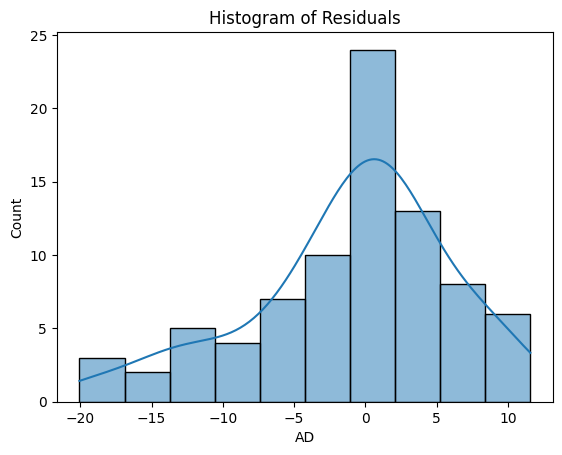

In [17]:
# Histogram + KDE
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

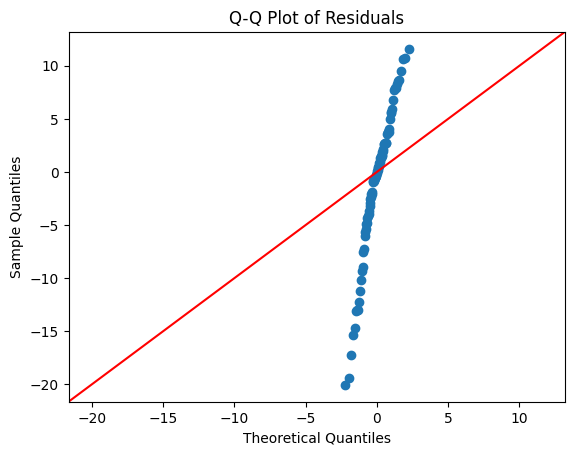

In [18]:
# Q-Q plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

as seen from the above plot, it strongly deviates from the line, especially in the tails. Hence the residuals are not normal.

In [19]:
stat, p = shapiro(residuals)
print(f'Shapiro-Wilk p-value: {p}')
if p < 0.05:
    print("Residuals are NOT normally distributed")
else:
    print("Residuals appear normal")

Shapiro-Wilk p-value: 0.005912904970575137
Residuals are NOT normally distributed


#### Constant Variance

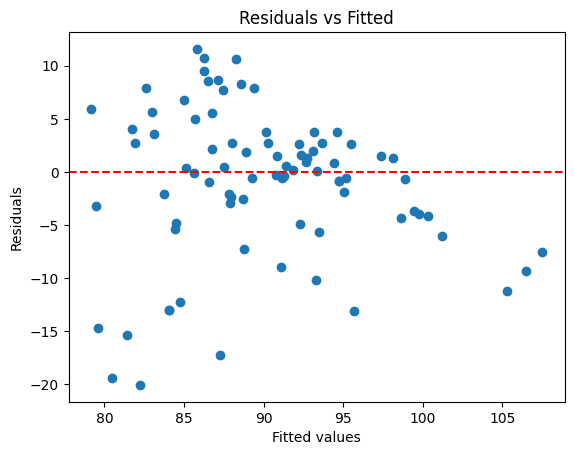

In [20]:
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

Plot shows funnel like pattern, hence suggesting heteroscedasticity. Model’s error variance is not constant.

In [22]:
# Convert back to DataFrame for statsmodels compatibility
X_train_df = pd.DataFrame(X_train, columns=['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"])
X_train_df = sm.add_constant(X_train_df)  # add intercept term

# Align indices for statsmodels
y_train_aligned = y_train.reset_index(drop=True)

# Refit model using statsmodels
sm_model = sm.OLS(y_train_aligned, X_train_df).fit()


In [24]:
# Get influence measures
influence = sm.OLS(y_train_aligned, X_train_df).fit().get_influence()

# Standardized residuals
standardized_residuals = influence.resid_studentized_internal

# Cook's distance
cooks_d = influence.cooks_distance[0]


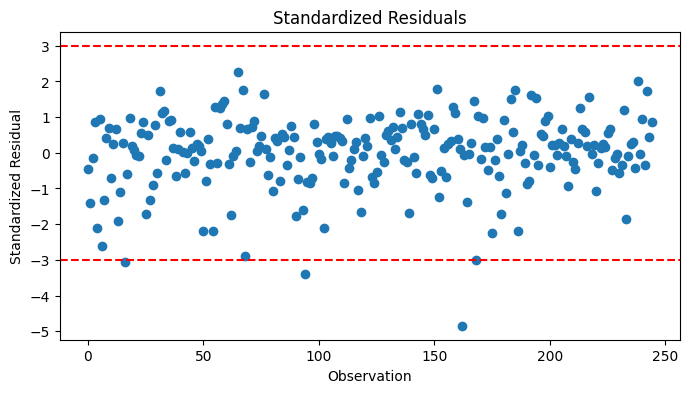

In [25]:
plt.figure(figsize=(8, 4))
plt.scatter(range(len(standardized_residuals)), standardized_residuals)
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title("Standardized Residuals")
plt.xlabel("Observation")
plt.ylabel("Standardized Residual")
plt.show()


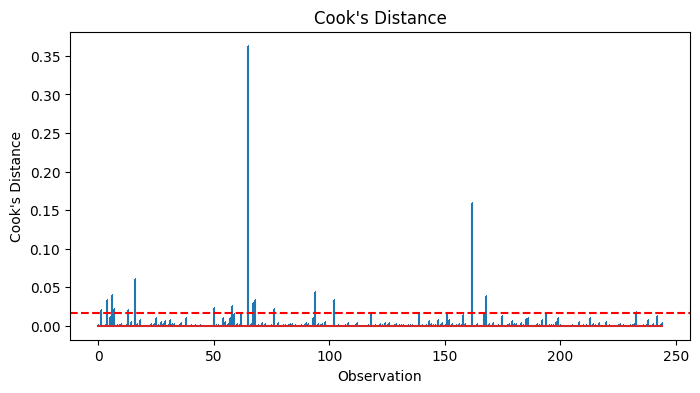

In [27]:
plt.figure(figsize=(8, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4 / len(X_train), color='red', linestyle='--')
plt.title("Cook's Distance")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.show()


In [28]:
outliers_std_resid = np.where(np.abs(standardized_residuals) > 3)[0]
outliers_cook = np.where(cooks_d > (4 / len(X_train)))[0]
print("Outliers based on standardized residuals:", outliers_std_resid)
print("Outliers based on Cook's distance:", outliers_cook)


Outliers based on standardized residuals: [ 16  94 162 168]
Outliers based on Cook's distance: [  1   4   6   7  13  16  50  58  62  65  67  68  76  94 102 162 168 194
 233]


checking these assumptions leads us to believe that the data need a transformation on the response variable. 